In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Optical Routing — Deep Dive

This page covers advanced optical routing features.
For a quick intro see [Routing Overview](overview.py).

| Topic | API |
|---|---|
| Waypoints | `route_bundle(..., waypoints=[...])` |
| Entry / exit stubs | `route_bundle(..., starts=..., ends=...)` |
| Path-length matching | `route_bundle(..., constraints=[kf.PathLengthMatch(...)], route_name=...)` |
| Loopback — inside variant | `route_loopback(..., inside=True)` |
| Direct backbone placement | `place_manhattan(c, p1, p2, pts, ...)` |

## Setup

All factories and ports must share the same `KCLayout` instance — here the global `kf.kcl`.

In [2]:
from functools import partial

import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

wg_enc = kf.kcl.get_enclosure(
    kf.LayerEnclosure(name="WGSTD_OPT", sections=[(L.WGCLAD, 0, 2_000)])
)

# Euler bend — width and radius in µm
bend90 = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
    width=0.5,
    radius=10,
    layer=L.WG,
    enclosure=wg_enc,
    angle=90,
)

# Straight factory — width and length in DBU
straight_factory = partial(
    kf.factories.straight.straight_dbu_factory(kcl=kf.kcl),
    layer=L.WG,
    enclosure=wg_enc,
)

WG_WIDTH = kf.kcl.to_dbu(0.5)  # 500 DBU

# Effective routing radius of the euler bend (larger than the nominal 10 µm)
bend_radius = kf.routing.optical.get_radius(bend90)

## 1 · Waypoints — guiding routes through fixed points

A `waypoints` value forces all routes to converge at a specific position and direction
before continuing to their end ports.

- Pass a `kdb.Trans` to specify a single convergence point with a direction.
- Pass a `list[kdb.Point]` to define a backbone corridor (direction inferred from
  the first two points).

Below, three East–West routes are forced to detour upward through a corridor at
y = 80 µm (simulating a gap above an obstacle) before descending to their
West-facing end ports.

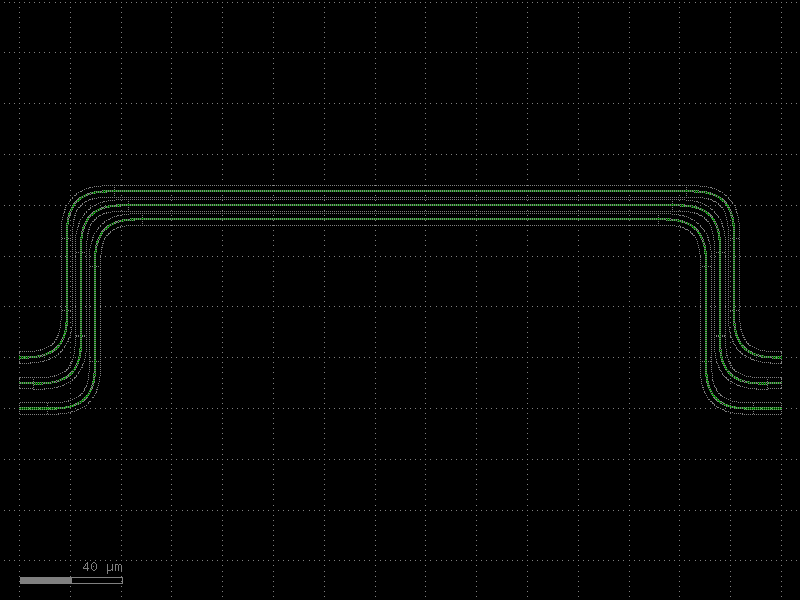

In [3]:
c_wp = kf.KCell("opt_waypoints")

n = 3
wp_starts = [
    kf.Port(
        name=f"in_{i}",
        # angle=0 → East-facing
        trans=kf.kdb.Trans(0, False, 0, kf.kcl.to_dbu(i * 10)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(n)
]
wp_ends = [
    kf.Port(
        name=f"out_{i}",
        # angle=2 → West-facing (opposite to East, so routes connect left-to-right)
        trans=kf.kdb.Trans(2, False, kf.kcl.to_dbu(300), kf.kcl.to_dbu(i * 10)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(n)
]

# Waypoint: at (150 µm, 80 µm) heading East.
# All routes must pass through this corridor before reaching their end ports.
kf.routing.optical.route_bundle(
    c_wp,
    wp_starts,
    wp_ends,
    separation=kf.kcl.to_dbu(5),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    waypoints=kf.kdb.Trans(0, False, kf.kcl.to_dbu(150), kf.kcl.to_dbu(80)),
)
c_wp

## 2 · Entry and exit stubs — `starts` and `ends`

`starts` / `ends` control how far each route must travel straight before the router
takes over.  Supplying a scalar applies the same stub length to all routes; a list
gives per-route control (DBU).

Stubs are useful when you need clearance from a device before bending, or when routing
out of a dense array.

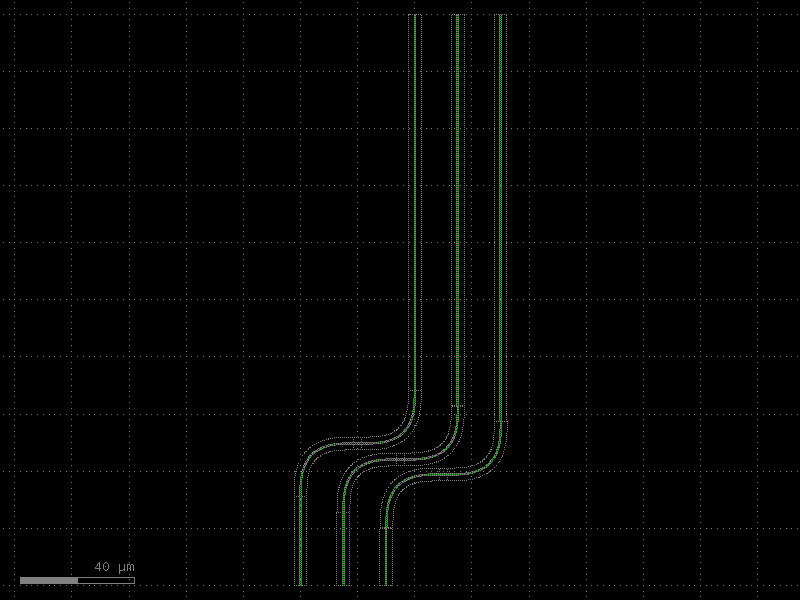

In [4]:
c_stubs = kf.KCell("opt_stubs")

stub_starts = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 15), 0),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
# End ports are offset 40 µm to the right of the start ports so each route
# has an S-bend whose entry / exit stubs are clearly visible.
stub_ends = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(40 + i * 15), kf.kcl.to_dbu(200)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]

# Each start port extends 20 µm straight before the bend, each end 10 µm.
kf.routing.optical.route_bundle(
    c_stubs,
    stub_starts,
    stub_ends,
    separation=kf.kcl.to_dbu(5),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    starts=kf.kcl.to_dbu(20),  # scalar → all routes get the same start stub
    ends=kf.kcl.to_dbu(10),
)
c_stubs

## 3 · Path-length matching

When routes travel different distances (e.g. fan-outs from an array where starts are
staggered), `kf.PathLengthMatch` inserts small "squiggle" loops on the shorter
routes so that all waveguide lengths become equal.  It runs as a *constraint* on
`route_bundle`: backbones are computed first, then the constraint walks the routers
of every bundle whose `route_name` it matches and rewrites the shorter ones.

**`PathLengthMatch` fields:**

| Field | Type | Meaning |
|---|---|---|
| `route_names` | `list[str]` | `route_name`s of the bundles to equalise |
| `element` | `int` | Which backbone segment to insert the loop into. `-1` = last segment. |
| `loop_side` | `int` | `-1` = loop on left, `0` = centered, `1` = loop on right |
| `loops` | `int` | Number of loop repetitions |
| `loop_position` | `int` | `-1` = near start of segment, `0` = center, `1` = near end |
| `length` | `int \| None` | Target path length in DBU. `None` = match the longest router. |
| `tolerance` | `int` | Maximum allowed length spread (DBU) after enforcement |

> **Note**: All routes must be routed first (the constraint runs after the
> backbones are generated), so routes need enough room for the inserted loops —
> increase `separation` or stagger ports as needed.

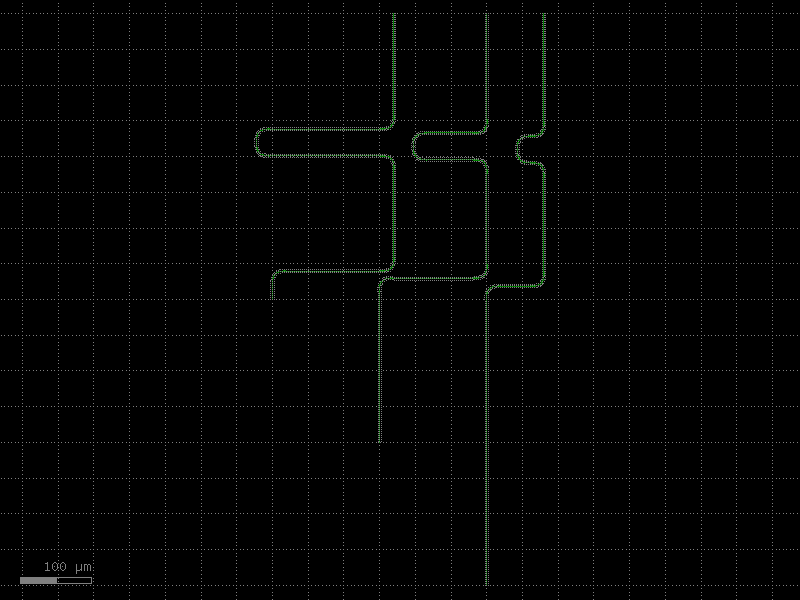

In [5]:
c_plm = kf.KCell("opt_path_length_match")

# Stagger start ports so that each route naturally has a different path length.
# Routes need sufficient horizontal separation (≥ 2× bend_radius) so the inserted
# loops don't overlap adjacent waveguides.
plm_starts = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 150), kf.kcl.to_dbu(-i * 200)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
plm_ends = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(x), kf.kcl.to_dbu(400)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i, x in enumerate([170, 300, 380])
]

kf.routing.optical.route_bundle(
    c_plm,
    plm_starts,
    plm_ends,
    separation=kf.kcl.to_dbu(10),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    constraints=[
        kf.PathLengthMatch(
            route_names=["plm_demo"],
            element=-1,  # insert loop in the last backbone segment
            loop_side=-1,  # loops on the left side
            loops=1,
            loop_position=0,  # centered in the segment
        )
    ],
    route_name="plm_demo",
)
c_plm

## 4 · Loopback — inside and outside variants (with GCs)

A loopback is a U-shaped waveguide tying two grating-couplers (GCs)
together so that light injected into one fibre comes out the other —
the canonical fibre-array alignment / reference structure.  The two
variants of `route_loopback` control where the U-turn fold sits
relative to the GC array:

- `inside=False` (default) places the U-turn fold *beyond* the array
  so the loopback hangs behind the GCs.  Use this when the rest of
  the routing area sits next to the array and the loopback must stay
  clear of the device footprint.
- `inside=True` folds the U-turn fold *between* the two GCs, so the
  loop's horizontal segment lives within the array's horizontal
  footprint.  Use this for compact reference structures where the
  loop must not extend past the array.

The fold needs room: aim for a GC pitch ≥ 4 × `bend_radius` for the
`inside` variant.  Below we use North-facing GCs spaced 150 µm apart
(≈ 8 × bend_radius) so both topologies render cleanly.

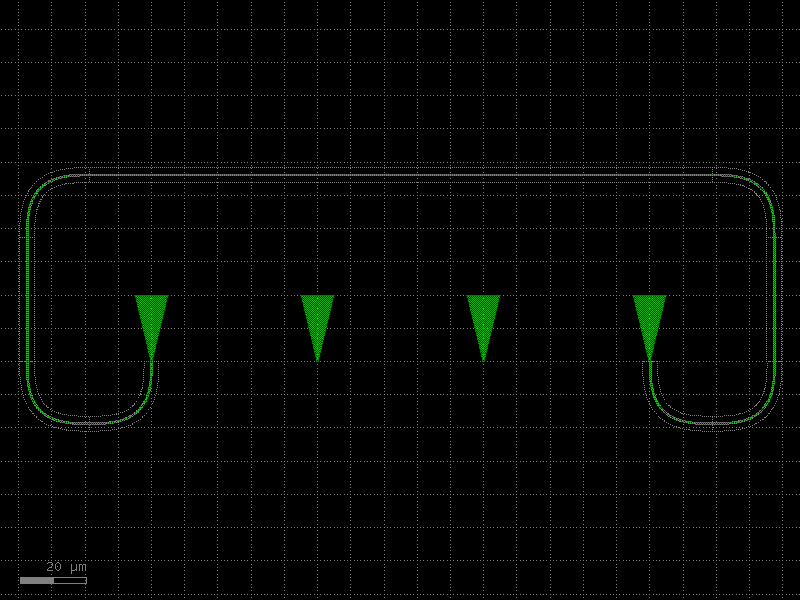

In [6]:
LB_SEP = kf.kcl.to_dbu(150)


# Grating-coupler stand-in: a taper with a single WG port at the narrow
# end.  The wide end (fibre side) extends north; the WG port faces south
# so the loopback's U-turn naturally curls *south* of the array.  In a
# real PDK this would be replaced by the actual GC component.
@kf.cell
def gc(width: int, length: int) -> kf.KCell:
    c = kf.KCell()
    wide = kf.kcl.to_dbu(10)
    poly = kf.kdb.Polygon(
        [
            kf.kdb.Point(-width // 2, 0),
            kf.kdb.Point(width // 2, 0),
            kf.kdb.Point(wide // 2, length),
            kf.kdb.Point(-wide // 2, length),
        ]
    )
    c.shapes(c.kcl.layer(L.WG)).insert(poly)
    c.create_port(
        name="o1",
        trans=kf.kdb.Trans(3, False, 0, 0),  # South-facing WG port
        width=width,
        layer_info=L.WG,
    )
    return c


gc_cell = gc(width=WG_WIDTH, length=kf.kcl.to_dbu(20))

# Pitch between adjacent GCs in the fibre array.  LB_SEP (defined above)
# is the spacing between the OUTERMOST two GCs — the ones the loopback
# connects.  The inner two GCs share the same pitch but are left free in
# this demo (in a real chip they would connect to devices).
N_GCS = 4
GC_PITCH_UM = kf.kcl.to_um(LB_SEP) / (N_GCS - 1)


# --- inside=False (outside loopback) ---
c_lb_outside = kf.KCell("opt_loopback_outside")

gcs_out = [c_lb_outside.create_inst(gc_cell) for _ in range(N_GCS)]
for i, inst in enumerate(gcs_out):
    inst.dmove((0, 0), (i * GC_PITCH_UM, 0))

# Loop only the two outermost GCs.
backbone_outside = kf.routing.optical.route_loopback(
    gcs_out[0].ports["o1"],
    gcs_out[-1].ports["o1"],
    bend90_radius=bend_radius,
    d_loop=bend_radius * 3,
    inside=False,
)

kf.routing.optical.place_manhattan(
    c_lb_outside,
    gcs_out[0].ports["o1"],
    gcs_out[-1].ports["o1"],
    backbone_outside,
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c_lb_outside

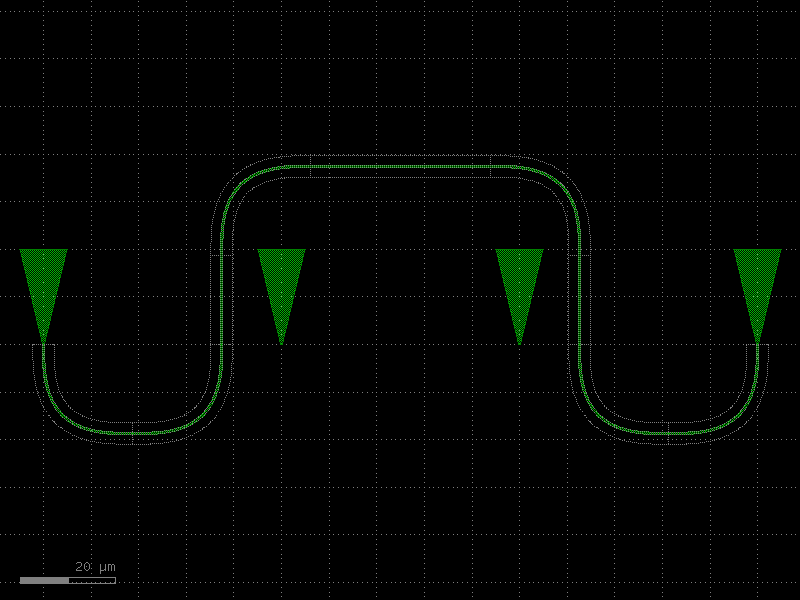

In [7]:
# --- inside=True (inner loopback — fold between the two outermost GCs) ---
c_lb_inside = kf.KCell("opt_loopback_inside")

gcs_in = [c_lb_inside.create_inst(gc_cell) for _ in range(N_GCS)]
for i, inst in enumerate(gcs_in):
    inst.dmove((0, 0), (i * GC_PITCH_UM, 0))

backbone_inside = kf.routing.optical.route_loopback(
    gcs_in[0].ports["o1"],
    gcs_in[-1].ports["o1"],
    bend90_radius=bend_radius,
    d_loop=bend_radius * 2,
    inside=True,
)

kf.routing.optical.place_manhattan(
    c_lb_inside,
    gcs_in[0].ports["o1"],
    gcs_in[-1].ports["o1"],
    backbone_inside,
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c_lb_inside

## 5 · Direct backbone placement with `place_manhattan`

`route_bundle` is the high-level router.  For full control you can build the backbone
yourself (a list of `kdb.Point`) and call `place_manhattan` directly to materialise
waveguide segments and bend cells along it.

This is the same function that `route_bundle` calls internally, exposed so that custom
routing algorithms can drive the placer.

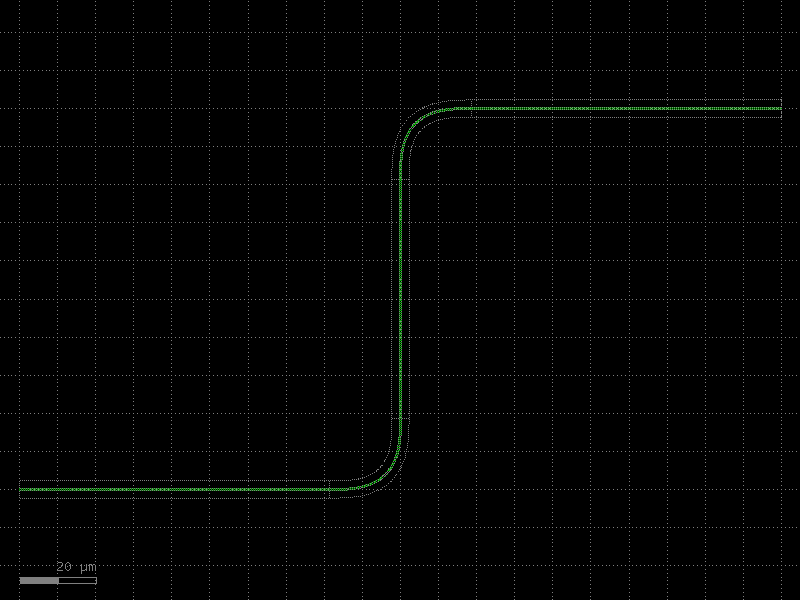

In [8]:
c_pm = kf.KCell("opt_place_manhattan_direct")

pm_p1 = kf.Port(
    name="o1",
    trans=kf.kdb.Trans(0, False, 0, 0),
    width=WG_WIDTH,
    layer_info=L.WG,
)
pm_p2 = kf.Port(
    name="o2",
    trans=kf.kdb.Trans(2, False, kf.kcl.to_dbu(200), kf.kcl.to_dbu(100)),
    width=WG_WIDTH,
    layer_info=L.WG,
)

# Hand-crafted Manhattan backbone: go East, then North, then West.
# Points are the *corners* of the route including the start and end positions.
custom_backbone = [
    kf.kdb.Point(0, 0),
    kf.kdb.Point(kf.kcl.to_dbu(100), 0),
    kf.kdb.Point(kf.kcl.to_dbu(100), kf.kcl.to_dbu(100)),
    kf.kdb.Point(kf.kcl.to_dbu(200), kf.kcl.to_dbu(100)),
]

kf.routing.optical.place_manhattan(
    c_pm,
    pm_p1,
    pm_p2,
    custom_backbone,
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c_pm

## Summary

| Need | Parameter / function |
|---|---|
| Route through a fixed corridor | `waypoints=[kdb.Point(...), ...]` |
| Guarantee minimum straight before bend | `starts=dbu_length` (scalar or per-route list) |
| Equalise optical path lengths | `constraints=[kf.PathLengthMatch(route_names=["b"], element=-1, loop_side=-1, loops=1, loop_position=0)]`, `route_name="b"` |
| Compact inner U-turn | `route_loopback(..., inside=True)` |
| Custom routing algorithm output | `place_manhattan(c, p1, p2, pts, straight_factory=..., bend90_cell=...)` |

All coordinates passed to `KCell`-based APIs are in **DBU** (1 nm = 1 DBU with default
`dbu=0.001`).  Convert with `kf.kcl.to_dbu(x_µm)`.

## See Also

| Topic | Where |
|-------|-------|
| Routing overview (optical + electrical entry point) | [Routing: Overview](overview.py) |
| Bundle routing details: sort, sbend, bbox modes | [Routing: Bundle](bundle.py) |
| Equal path-length loops | [Routing: Path Length](path_length.py) |
| Low-level backbone + Steps API | [Routing: Manhattan](manhattan.py) |
| All-angle (non-manhattan) routing | [Routing: All-Angle](all_angle.py) |
| Euler bend effective radius | [Components: Euler Bends](../components/cells/factories/euler.py) |
| Port construction and connection | [Core Concepts: Ports](../concepts/ports.py) |